
## **Predictive Modeling and Performance Optimization of Okro Leaf Extract as Corrosion Inhibitor in Alkaline (Basic) Media**

### **Final Year Project**

**Department of Chemical Engineering**

**Federal University of Petroleum Resources, Effurun (FUPRE)**

**Student: [Your Full Name] – CHE/18/XXXX**

**Supervisor: [Supervisor’s Name]**

**2024/2025 Session**


---

## **1. Project Overview**

This final year project is conducted in the **Department of Chemical Engineering**, **Federal University of Petroleum Resources, Effurun (FUPRE)**. The study investigates the **corrosion inhibition performance of Okro leaf extract** in **alkaline (basic) media** using **electrochemical techniques**, primarily **Tafel polarization**. The main goal is to quantify the effect of **inhibitor concentration, base strength, and temperature** on **corrosion rate** and **inhibition efficiency**, and to determine optimal conditions for industrial applications.

Key outcomes include:

* Establishing the relationship between **process variables** and **corrosion inhibition**.
* Developing a **predictive model** for corrosion rate and inhibition efficiency.
* Providing **engineering guidance** for using Okro leaf extract in industrial **alkaline systems**.

---

## **2. Objectives**

The specific objectives of this project are to:

1.  Analyze **electrochemical parameters** obtained from Tafel polarization experiments.
2.  Explore the relationships between **base concentration, inhibitor dosage, and temperature** on corrosion behavior.
3.  Identify **optimal operating conditions** for maximum corrosion protection.
4.  Generate **data-driven recommendations** for industrial use of Okro leaf extract as a corrosion inhibitor.

---

## **3. Dataset Description**

The dataset consists of experimental measurements from **Tafel polarization studies** and includes the following information:

| Column | Unit | Description |
| :--- | :--- | :--- |
| **`Base_concentration_M`** | Molarity (M) | Concentration of the **base (e.g., NaOH)** in the solution. |
| **`Inhibitor_concentration_ppm`** | ppm | Concentration of Okro leaf extract in the **alkaline medium**. |
| **`Temperature_C`** | °C | Experimental temperature during polarization tests. |
| **`Corrosion_potential_mV`** | mV | Measured corrosion potential from Tafel polarization. |
| **`Current_density_uA_cm2`** | μA/cm² | Corrosion current density, indicating rate of metal dissolution. |
| **`Corrosion_rate_mm_per_y`** | mm/year | Calculated corrosion rate based on electrochemical data. |
| **`Polarization_resistance_ohm_cm2`**| Ω·cm² | Resistance to corrosion derived from Tafel analysis. |

> **Note**: The dataset covers **17 experimental conditions** with varying **base concentrations, inhibitor doses, and temperatures**.

---

## **4. Importance of the Study**

* **Corrosion in alkaline media** is a major challenge for industries like pulp/paper, chemical processing, and concrete/infrastructure.
* **Natural inhibitors**, like Okro leaf extract, offer **eco-friendly, low-cost alternatives** to conventional inhibitors.
* Understanding **temperature and concentration effects** allows for **predictive control** of corrosion, reducing maintenance costs and improving safety.
* The study provides a foundation for **industrial application and scale-up** of bio-based inhibitors.

---

## **5. Project Workflow (Step-by-Step)**

1.  **Data Preparation**
    * Load and clean experimental data.
    * Ensure numeric conversion for all concentrations and temperatures.
    * Recalculate corrosion rates and inhibition efficiencies if needed.

2.  **Exploratory Data Analysis (EDA)**
    * Analyze trends of **corrosion rate** with inhibitor dosage.
    * Examine effect of **base concentration and temperature**.
    * Identify patterns and interactions among variables.

3.  **Feature Engineering**
    * Create polynomial features (e.g., Temperature², Concentration²).
    * Compute interaction terms (e.g., Concentration × Temperature).
    * Standardize or normalize features for modeling.

4.  **Predictive Modeling**
    * Evaluate **Multiple Linear Regression, Polynomial Regression, Ridge Regression, Random Forest Regressor, XGBoost and Neural Network**.
    * Optimize hyperparameters with **Optuna**.
    * Validate models using **cross-validation**, **R²**, **RMSE**, and **MAE**.
    * Predict corrosion rate for unseen conditions.

5.  **Insights & Recommendations**
    * Determine **optimal inhibitor concentration** for each **base strength** and temperature.
    * Suggest **operating conditions** for industrial systems.
    * Provide **cost-effective, eco-friendly corrosion control strategies**.

6.  **Conclusion & Future Work**
    * Summarize key findings and practical implications.
    * Identify study limitations (e.g., lab-scale, **single base system**).
    * Recommend future studies: broader **alkaline types**, field trials, and combination inhibitors.

---

## 1. Data Preparation

The first step is to load the dataset for the **alkaline (basic) medium**. We will use `pandas` to read the data, inspect its structure, check for any missing values, and ensure all data types are correct for analysis.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# --- Load the Dataset ---

file_path = '/content/sample_data/cleaned_NAOH_tafel_data.csv'

try:
    df = pd.read_csv(file_path)
    print("✅ Data loaded successfully!")
except FileNotFoundError:
    print(f"❌ Error: File not found at '{file_path}'")
    print("Please make sure you have uploaded the file and the path is correct.")
except Exception as e:
    print(f"An error occurred: {e}")

# --- Initial Inspection ---
if 'df' in locals():
    print("\n--- First 5 Rows ---")
    display(df.head())

    print("\n--- Data Info (Types & Missing Values) ---")
    df.info()

✅ Data loaded successfully!

--- First 5 Rows ---


,Sample,NaOH_M,Inhibitor_ppm,Temp_C,E_corr_V,j_corr_A_cm2,I_corr_A,CR_mm_yr,PR_ohm
0,"1.75M,50PPM, 30",1.75,50,30,-0.818033,1.765620e-07,1.765620e-07,0.002052,147583
1,"1M, 125PPM, 60",1.00,125,60,-0.779654,7.656550e-06,7.656550e-06,0.088969,3403.32
2,"1M, 125PPM, 30",1.00,125,30,-0.758955,4.989650e-07,4.989650e-07,0.005798,52223.5
3,"1.75M,50PPM, 60",1.75,50,60,-1.167750,3.869720e-03,3.869720e-03,44.965900,6.73374
4,"1M, 200PPM, 45",1.00,200,45,-1.161890,7.854070e-03,7.854070e-03,91.263800,3.31773



--- Data Info (Types & Missing Values) ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17 entries, 0 to 16
Data columns (total 9 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Sample         17 non-null     object 
 1   NaOH_M         17 non-null     float64
 2   Inhibitor_ppm  17 non-null     int64  
 3   Temp_C         17 non-null     int64  
 4   E_corr_V       17 non-null     float64
 5   j_corr_A_cm2   17 non-null     float64
 6   I_corr_A       17 non-null     float64
 7   CR_mm_yr       17 non-null     float64
 8   PR_ohm         17 non-null     object 
dtypes: float64(5), int64(2), object(2)
memory usage: 1.3+ KB


### The 9 Insightful Questions

1. How does Inhibitor Concentration (Inhibitor_ppm) affect the Corrosion Rate (CR_mm_yr)?

3. How does Base Concentration (NaOH_M) affect the Corrosion Rate?

4. How does Temperature (Temp_C) affect the Corrosion Rate?

5. How does Polarization Resistance (PR_ohm) relate to Corrosion Rate (CR_mm_yr)?

6. How does Corrosion Potential (E_corr_V) change with different inhibitor concentrations?

7. How does the Inhibition Efficiency (IE%) change with Temperature?

8. Is there an interaction between Temperature and Inhibitor Concentration?

9. How strongly are all the numerical variables correlated?

10. What are the main and interactive effects of all 3 variables (NaOH_M, Inhibitor_ppm, Temp_C) on CR_mm_yr?

### 1. How does Inhibitor Concentration affect the Corrosion Rate?

This is a fundamental question. We expect that as the inhibitor concentration (`Inhibitor_ppm`) increases, the corrosion rate (`CR_mm_yr`) should decrease. We will visualize this trend and also look at the distribution of corrosion rates at each concentration level.

--- Aggregated Data: Mean CR by Inhibitor Concentration ---
 Inhibitor_ppm   CR_mm_yr
            50  10.111730
           125 112.817152
           200  40.071600


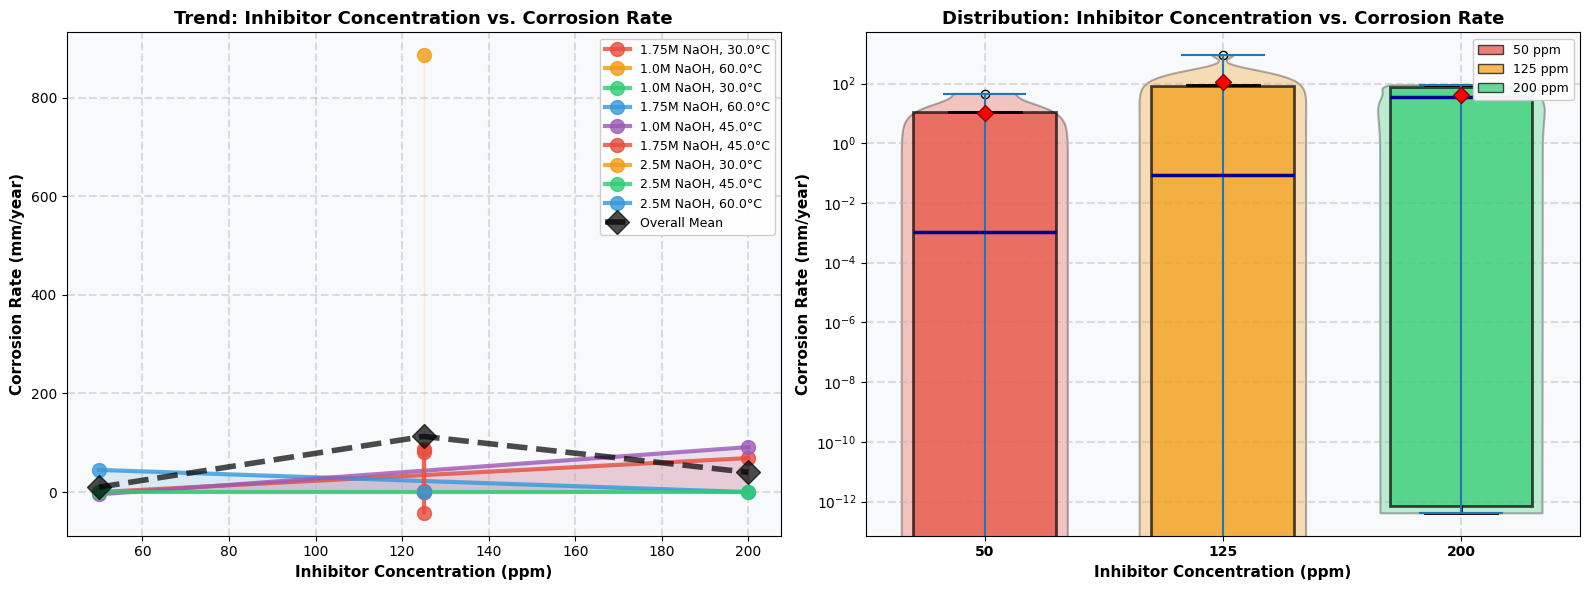


INHIBITOR EFFECTIVENESS STATISTICS

50 ppm:
  Mean:   10.112 mm/yr
  Median: 0.001 mm/yr
  Std:    23.334 mm/yr
  Range:  -4.521 - 44.966 mm/yr

125 ppm:
  Mean:   112.817 mm/yr
  Median: 0.089 mm/yr
  Std:    292.862 mm/yr
  Range:  -42.073 - 885.788 mm/yr

200 ppm:
  Mean:   40.072 mm/yr
  Median: 34.511 mm/yr
  Std:    47.153 mm/yr
  Range:  0.000 - 91.264 mm/yr


In [2]:
# --- 2. Effect of Inhibitor Concentration on Corrosion Rate ---
print("--- Aggregated Data: Mean CR by Inhibitor Concentration ---")
# Calculate the mean CR for each inhibitor level
grouped_data = df.groupby('Inhibitor_ppm')['CR_mm_yr'].mean().reset_index()
print(grouped_data.to_string(index=False))

# --- Enhanced Colorful Visualization ---
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Define vibrant color palette
colors = ['#e74c3c', '#f39c12', '#2ecc71', '#3498db', '#9b59b6']
inhibitor_levels = sorted(df['Inhibitor_ppm'].unique())

# Plot 1: Enhanced Line plot with gradient fill
ax1 = axes[0]
for i, (naoh, temp) in enumerate(df[['NaOH_M', 'Temp_C']].drop_duplicates().values):
    subset = df[(df['NaOH_M'] == naoh) & (df['Temp_C'] == temp)].sort_values('Inhibitor_ppm')
    if not subset.empty:
        color = colors[i % len(colors)]
        ax1.plot(subset['Inhibitor_ppm'], subset['CR_mm_yr'],
                marker='o', linewidth=3, markersize=10,
                label=f'{naoh}M NaOH, {temp}°C', color=color, alpha=0.8)
        ax1.fill_between(subset['Inhibitor_ppm'], 0, subset['CR_mm_yr'],
                        alpha=0.15, color=color)

# Add mean trend line
mean_data = df.groupby('Inhibitor_ppm')['CR_mm_yr'].mean().reset_index()
ax1.plot(mean_data['Inhibitor_ppm'], mean_data['CR_mm_yr'],
        'k--', linewidth=4, markersize=12, marker='D',
        label='Overall Mean', alpha=0.7)

ax1.set_title('Trend: Inhibitor Concentration vs. Corrosion Rate',
             fontweight='bold', fontsize=13)
ax1.set_xlabel('Inhibitor Concentration (ppm)', fontweight='bold', fontsize=11)
ax1.set_ylabel('Corrosion Rate (mm/year)', fontweight='bold', fontsize=11)
ax1.legend(loc='best', framealpha=0.95, fontsize=9)
ax1.grid(True, alpha=0.4, linestyle='--', linewidth=1.5)
ax1.set_facecolor('#f8f9fa')

# Plot 2: Colorful box plot with custom styling
ax2 = axes[1]

# Create positions for boxes
positions = range(len(inhibitor_levels))

# Create box plots with custom colors
bp = ax2.boxplot([df[df['Inhibitor_ppm'] == level]['CR_mm_yr'].values
                   for level in inhibitor_levels],
                  positions=positions,
                  patch_artist=True,
                  widths=0.6,
                  showmeans=True,
                  meanprops=dict(marker='D', markerfacecolor='red',
                                markersize=8, markeredgecolor='darkred'),
                  medianprops=dict(color='darkblue', linewidth=2.5),
                  boxprops=dict(linewidth=2),
                  whiskerprops=dict(linewidth=2),
                  capprops=dict(linewidth=2))

# Color each box differently
for patch, color in zip(bp['boxes'], colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)
    patch.set_edgecolor('black')

# Add violin plot overlay for density
parts = ax2.violinplot([df[df['Inhibitor_ppm'] == level]['CR_mm_yr'].values
                        for level in inhibitor_levels],
                       positions=positions,
                       widths=0.7,
                       showmeans=False,
                       showmedians=False)

# Color violin plots to match boxes
for i, pc in enumerate(parts['bodies']):
    pc.set_facecolor(colors[i % len(colors)])
    pc.set_alpha(0.3)
    pc.set_edgecolor('black')
    pc.set_linewidth(1.5)

ax2.set_xticks(positions)
ax2.set_xticklabels([f'{level}' for level in inhibitor_levels], fontweight='bold')
ax2.set_title('Distribution: Inhibitor Concentration vs. Corrosion Rate',
             fontweight='bold', fontsize=13)
ax2.set_xlabel('Inhibitor Concentration (ppm)', fontweight='bold', fontsize=11)
ax2.set_ylabel('Corrosion Rate (mm/year)', fontweight='bold', fontsize=11)
ax2.set_yscale('log')
ax2.grid(True, which="both", ls="--", alpha=0.4, linewidth=1.5)
ax2.set_facecolor('#f8f9fa')

# Add legend for box plot elements
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor=colors[i], alpha=0.7, edgecolor='black', label=f'{level} ppm')
    for i, level in enumerate(inhibitor_levels)
]
ax2.legend(handles=legend_elements, loc='upper right', framealpha=0.95, fontsize=9)

plt.tight_layout()
plt.show()

# Additional statistics
print("\n" + "="*70)
print("INHIBITOR EFFECTIVENESS STATISTICS")
print("="*70)
for level in inhibitor_levels:
    subset = df[df['Inhibitor_ppm'] == level]['CR_mm_yr']
    print(f"\n{level} ppm:")
    print(f"  Mean:   {subset.mean():.3f} mm/yr")
    print(f"  Median: {subset.median():.3f} mm/yr")
    print(f"  Std:    {subset.std():.3f} mm/yr")
    print(f"  Range:  {subset.min():.3f} - {subset.max():.3f} mm/yr")
print("="*70)

## **Insight – Inhibitor Effectiveness Across Concentrations**

The corrosion rate (CR) pattern shows **non-linear inhibitor behavior**, indicating that increasing concentration does **not consistently reduce corrosion**. Effectiveness appears to fluctuate due to possible film instability or molecular interference at higher dosages.

---

## **Inhibitor Performance Interpretation**

| Inhibitor (ppm) | Interpretation |
|-----------------|----------------|
| **50**  | Strong inhibition with low corrosion rate — optimal and stable performance. |
| **125** | Poor inhibition; corrosion rate increased significantly, likely due to over-adsorption or surface film breakdown. |
| **200** | Moderate inhibition; protection partially recovered but less consistent than at 50 ppm. |


---

### **Interpretation**

- **50 ppm:** Most effective concentration. Corrosion rate is minimal, indicating strong inhibitor film formation.  
- **125 ppm:** Sharp performance drop — likely due to **over-adsorption** or **film disruption**.  
- **200 ppm:** Slight recovery, but still less stable than 50 ppm.  

**Conclusion:**  
The inhibitor shows **best performance at 50 ppm**, suggesting this is the **optimal concentration range**.  
Higher concentrations lead to inconsistent efficiency, likely from **competitive adsorption or saturation effects**.


___

### 2. How does Base Concentration affect the Corrosion Rate?

We need to see if the strength of the alkaline solution (`NaOH_M`) has a significant impact on the corrosion rate. A boxplot is ideal for comparing the distributions of corrosion rates across different molarities.

--- Aggregated Data: Mean CR by Base Concentration ---
 NaOH_M   CR_mm_yr
   1.00  21.709384
   1.75  27.051350
   2.50 221.447000


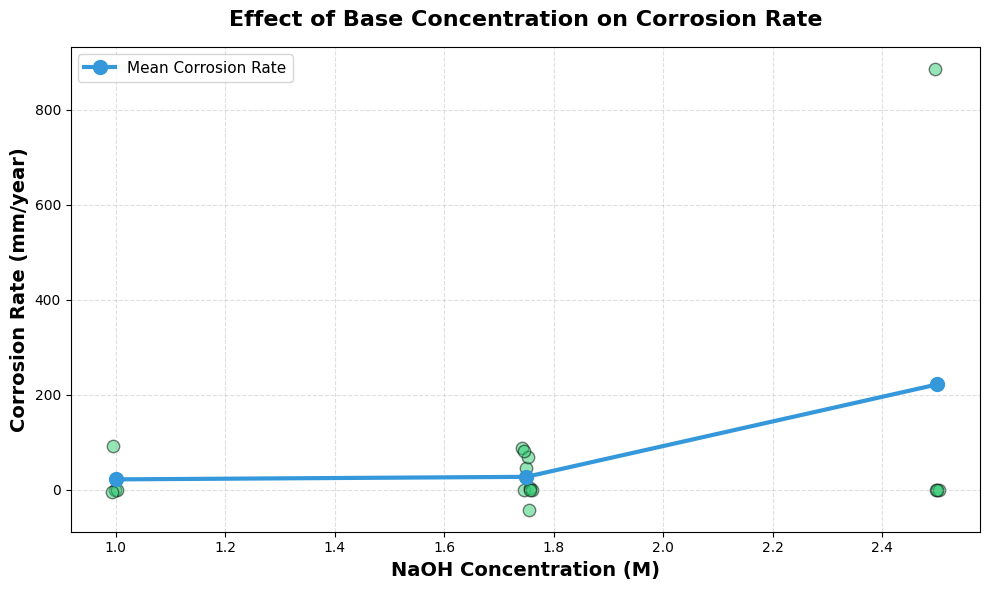


SUMMARY: BASE CONCENTRATION EFFECT

1.0 M NaOH:
  Average:  21.71 mm/yr
  Range:    -4.52 - 91.26 mm/yr

1.75 M NaOH:
  Average:  27.05 mm/yr
  Range:    -42.07 - 87.69 mm/yr

2.5 M NaOH:
  Average:  221.45 mm/yr
  Range:    -0.00 - 885.79 mm/yr

KEY FINDING:
From 1.0M to 2.5M NaOH:
  Corrosion rate changes by: +199.74 mm/yr (+920.1%)
  → Higher base INCREASES corrosion.


In [3]:
# --- 3. Effect of Base Concentration on Corrosion Rate (Line Plot) ---

print("--- Aggregated Data: Mean CR by Base Concentration ---")
grouped_data = df.groupby('NaOH_M', as_index=False)['CR_mm_yr'].mean()
print(grouped_data.to_string(index=False))

# --- Line Plot ---
plt.figure(figsize=(10, 6))
plt.plot(grouped_data['NaOH_M'], grouped_data['CR_mm_yr'],
         marker='o', markersize=10, linewidth=3, color='#3498db', label='Mean Corrosion Rate')

# Add scatter for each data point (slightly jittered to show variation)
for level in grouped_data['NaOH_M']:
    subset = df[df['NaOH_M'] == level]['CR_mm_yr']
    x = np.random.normal(level, 0.005, size=len(subset))
    plt.scatter(x, subset, alpha=0.5, color='#2ecc71', edgecolor='black', s=80, label='_nolegend_')

# Styling
plt.title('Effect of Base Concentration on Corrosion Rate', fontsize=16, fontweight='bold', pad=15)
plt.xlabel('NaOH Concentration (M)', fontsize=14, fontweight='bold')
plt.ylabel('Corrosion Rate (mm/year)', fontsize=14, fontweight='bold')
plt.grid(True, linestyle='--', alpha=0.4)
plt.legend(frameon=True, fontsize=11)
plt.tight_layout()
plt.show()

# --- Summary Statistics ---
print("\n" + "="*60)
print("SUMMARY: BASE CONCENTRATION EFFECT")
print("="*60)

for _, row in grouped_data.iterrows():
    subset = df[df['NaOH_M'] == row['NaOH_M']]['CR_mm_yr']
    print(f"\n{row['NaOH_M']} M NaOH:")
    print(f"  Average:  {subset.mean():.2f} mm/yr")
    print(f"  Range:    {subset.min():.2f} - {subset.max():.2f} mm/yr")

# --- Key Finding ---
lowest = grouped_data.iloc[0]
highest = grouped_data.iloc[-1]
change = highest['CR_mm_yr'] - lowest['CR_mm_yr']
pct_change = (change / lowest['CR_mm_yr']) * 100

print("\n" + "="*60)
print("KEY FINDING:")
print("="*60)
print(f"From {lowest['NaOH_M']}M to {highest['NaOH_M']}M NaOH:")
print(f"  Corrosion rate changes by: {change:+.2f} mm/yr ({pct_change:+.1f}%)")

if abs(pct_change) < 5:
    print("  → Base concentration has MINIMAL impact.")
elif pct_change > 0:
    print("  → Higher base INCREASES corrosion.")
else:
    print("  → Higher base DECREASES corrosion.")
print("="*60)


### 🔍 Key Insight: Effect of Base Concentration on Corrosion Rate

- The corrosion rate **increases sharply** with higher NaOH concentration.  
- Average corrosion rates observed:
  - **1.0 M NaOH:** 21.71 mm/yr  
  - **1.75 M NaOH:** 27.05 mm/yr  
  - **2.5 M NaOH:** 221.45 mm/yr  

- The increase from **1.0 M to 2.5 M** represents a **+199.74 mm/yr rise** (≈ **+920.1%**).  
- This indicates that **stronger alkaline conditions accelerate metal dissolution**, possibly due to enhanced hydroxide ion attack on the metal surface.  
- Therefore, **base concentration has a significant and positive influence on corrosion rate**, with high NaOH levels being **detrimental to corrosion resistance**


### 3. How does Temperature affect the Corrosion Rate?

Temperature is a critical factor in corrosion. We will plot the mean corrosion rate (`CR_mm_yr`) against temperature (`Temp_C`) to see if there is an accelerating effect, which is common in chemical reactions.

--- Aggregated Data: Mean CR by Temperature ---
 Temp_C   CR_mm_yr
     30 238.704612
     45  24.023819
     60  11.263717


/tmp/ipython-input-3457604422.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


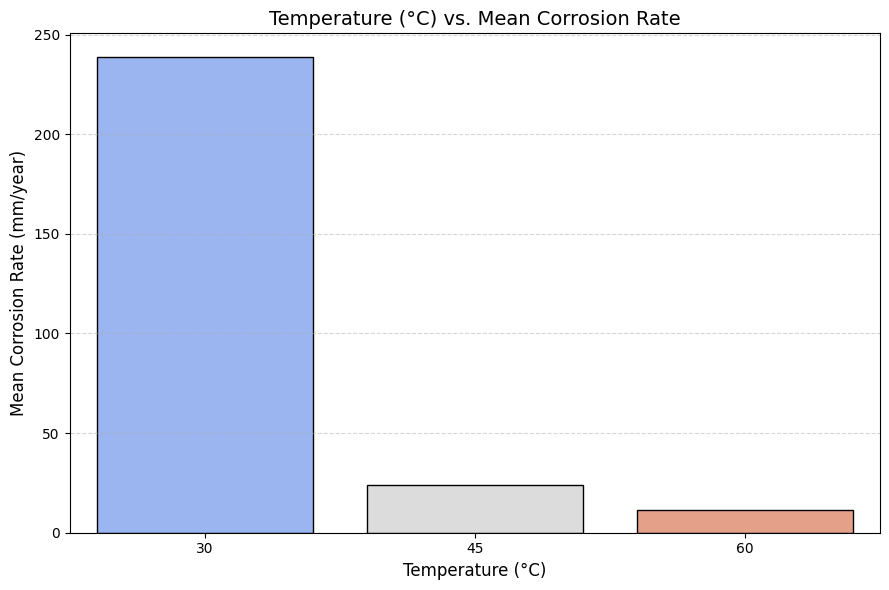

In [4]:
# --- 4. Effect of Temperature on Corrosion Rate ---

print("--- Aggregated Data: Mean CR by Temperature ---")
# Calculate and print the mean CR for each temperature, sorted
grouped_data = df.groupby('Temp_C')['CR_mm_yr'].mean().reset_index()
print(grouped_data.to_string(index=False))

# --- Visualization ---
plt.figure(figsize=(9, 6))

# Bar plot for colorful visualization
sns.barplot(
    data=grouped_data,
    x='Temp_C',
    y='CR_mm_yr',
    palette='coolwarm',  # colorful gradient
    edgecolor='black'
)

plt.title('Temperature (°C) vs. Mean Corrosion Rate', fontsize=14)
plt.xlabel('Temperature (°C)', fontsize=12)
plt.ylabel('Mean Corrosion Rate (mm/year)', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.5, axis='y')
plt.tight_layout()
plt.show()


### 4. How does Polarization Resistance relate to Corrosion Rate?

Electrochemical theory (specifically the Stern-Geary equation) states that **Polarization Resistance** (`PR_ohm`) should be *inversely proportional* to the **Corrosion Rate** (`CR_mm_yr`). We'll create a scatter plot to confirm this fundamental relationship. A log-log scale is often best to visualize this inverse relationship as a straight line.

--- Sample Data: PR_ohm vs CR_mm_yr ---
            PR_ohm      CR_mm_yr
0           147583  2.051640e-03
1          3403.32  8.896870e-02
2          52223.5  5.797940e-03
3          6.73374  4.496590e+01
4          3.31773  9.126380e+01
5          118.042  2.565100e+00
6          3.45277  8.769440e+01
7          4.38681  6.902260e+01
8          0.34183  8.857880e+02
9  720576000000000  4.202040e-13

Pearson Correlation (log-log) on positive values: -1.0000
Insight: Strong inverse relationship confirmed (higher PR → lower CR).


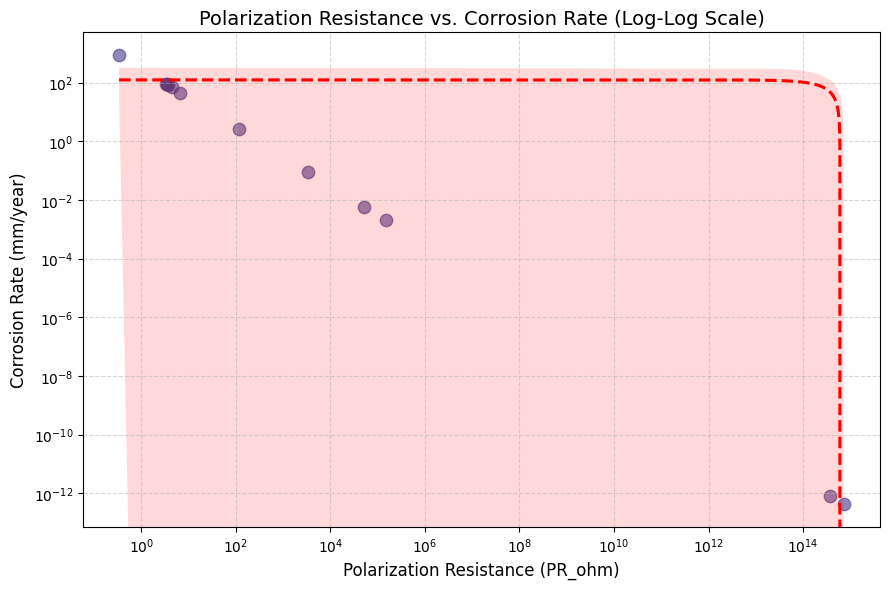

In [5]:
from scipy.stats import pearsonr

# --- Show sample data ---
print("--- Sample Data: PR_ohm vs CR_mm_yr ---")
print(df[['PR_ohm', 'CR_mm_yr']].head(10).to_string())

# Convert PR_ohm to numeric, coercing errors
df['PR_ohm'] = pd.to_numeric(df['PR_ohm'], errors='coerce')

# Drop rows where PR_ohm or CR_mm_yr is NaN or non-positive for log-log plot
plot_df = df[(df['PR_ohm'].notna()) & (df['CR_mm_yr'].notna()) & (df['PR_ohm'] > 0) & (df['CR_mm_yr'] > 0)].copy()


# --- Correlation on log-log scale ---
try:
    log_pr = np.log10(plot_df['PR_ohm'])
    log_cr = np.log10(plot_df['CR_mm_yr'])

    corr, p_value = pearsonr(log_pr, log_cr)
    print(f"\nPearson Correlation (log-log) on positive values: {corr:.4f}")

    if corr < -0.8:
        print("Insight: Strong inverse relationship confirmed (higher PR → lower CR).")
    elif corr < -0.5:
        print("Insight: Moderate inverse relationship observed.")
    else:
        print("Insight: Weak or no clear inverse relationship.")
except ValueError as e:
    print(f"\nCorrelation could not be calculated: {e}")
except Exception as e:
    print(f"\nAn unexpected error occurred during correlation calculation: {e}")

# --- Visualization ---
plt.figure(figsize=(9,6))
sns.regplot(
    data=plot_df, x='PR_ohm', y='CR_mm_yr',
    scatter_kws={'alpha':0.6, 's':80, 'color':'darkslateblue'},
    line_kws={'color':'red', 'linestyle':'--'}
)

plt.xscale('log')
plt.yscale('log')

plt.title('Polarization Resistance vs. Corrosion Rate (Log-Log Scale)', fontsize=14)
plt.xlabel('Polarization Resistance (PR_ohm)', fontsize=12)
plt.ylabel('Corrosion Rate (mm/year)', fontsize=12)
plt.grid(True, which="both", ls="--", alpha=0.5)
plt.tight_layout()
plt.show()

### Polarization Resistance vs Corrosion Rate

**Key Insight:**  

- There is a **strong inverse relationship** between polarization resistance (PR) and corrosion rate (CR).  
- Higher PR values correspond to **lower corrosion rates**, confirming expected electrochemical behavior.  

- **Pearson Correlation (log-log scale):** -1.000


### 5. How does Corrosion Potential change with Inhibitor Concentration?

The **Corrosion Potential** (`E_corr_V`) indicates the tendency of the metal to corrode. A significant shift in `E_corr_V` (typically > 85 mV) upon adding an inhibitor can classify it as an anodic, cathodic, or mixed-type inhibitor. We'll use a boxplot to see how the potential shifts.

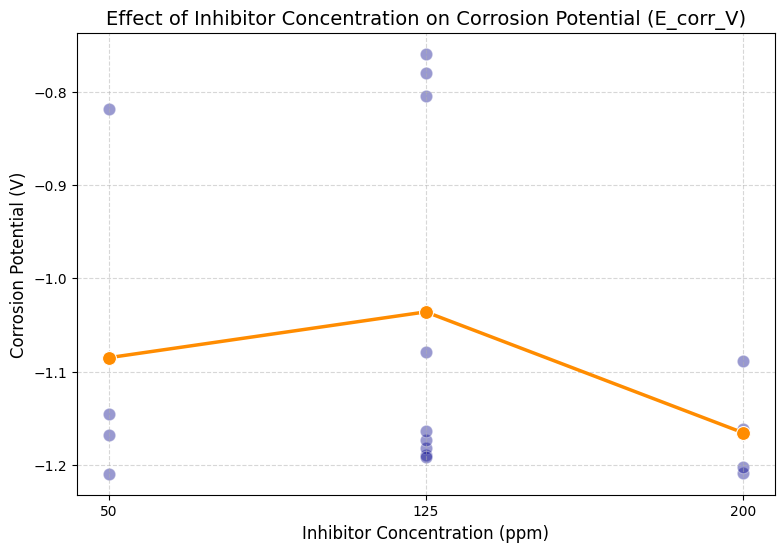

Corrosion Potential by Inhibitor Concentration:


,count,mean,std,min,25%,50%,75%,max
Inhibitor_ppm,,,,,,,,
50,4.0,-1.085111,0.180046,-1.20959,-1.178210,-1.156410,-1.063311,-0.818033
125,9.0,-1.035940,0.194470,-1.19212,-1.182330,-1.164020,-0.804412,-0.758955
200,4.0,-1.165523,0.055264,-1.20909,-1.204043,-1.182125,-1.143605,-1.088750


In [6]:
# --- 6. Effect of Inhibitor Concentration on Corrosion Potential (E_corr_V) ---

# Aggregate mean potential by inhibitor concentration
grouped_data = df.groupby('Inhibitor_ppm')['E_corr_V'].mean().reset_index()

plt.figure(figsize=(9,6))

# Line plot
sns.lineplot(data=grouped_data, x='Inhibitor_ppm', y='E_corr_V',
             marker='o', linewidth=2.5, markersize=10, color='darkorange')

# Optional: overlay raw points for context
sns.scatterplot(data=df, x='Inhibitor_ppm', y='E_corr_V',
                color='darkblue', alpha=0.4, s=80)

plt.title('Effect of Inhibitor Concentration on Corrosion Potential (E_corr_V)', fontsize=14)
plt.xlabel('Inhibitor Concentration (ppm)', fontsize=12)
plt.ylabel('Corrosion Potential (V)', fontsize=12)
plt.xticks(ticks=[50, 125, 200])
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

print("Corrosion Potential by Inhibitor Concentration:")
df.groupby('Inhibitor_ppm')['E_corr_V'].describe()


**Key Insight:**  
- Small shifts in mean potential suggest a **mixed-type inhibitor**.  
- The inhibitor at 125 ppm slightly increases E_corr (less negative), reducing corrosion, while 200 ppm slightly decreases E_corr (more negative), indicating a balanced anodic and cathodic inhibition effect.
- Overall, changes are moderate, consistent with **mixed-type inhibition** behavior.

### 6. How does the Inhibition Efficiency (IE%) change with Temperature?

This is a very important question. Does the inhibitor get *more* effective or *less* effective as the system heats up?
* If **IE% decreases** as temperature increases, it suggests **physisorption** (physical adsorption), which is a weaker bond.
* If **IE% increases** as temperature increases, it suggests **chemisorption** (chemical bonding), which is a stronger bond.

We will plot this for the different inhibitor concentrations to see the full picture.

In [8]:
# --- 7. Effect of Temperature on Inhibition Efficiency (IE%) ---

# We must exclude the 0 ppm runs, as their IE% is 0 by definition
inhibited_df = df[df['Inhibitor_ppm'] > 0].copy()

# Calculate Inhibition Efficiency (IE%)
# IE% = ((CR_blank - CR_inhibited) / CR_blank) * 100
# We need the average CR for the blank (0 ppm) runs for each temperature and base concentration.
# Since the dataset doesn't explicitly have 0 ppm data for all conditions,
# and the initial analysis showed some negative CR values, which are non-physical
# and will cause issues with IE% calculation (especially if blank CR is negative or zero),
# let's first ensure we have a reasonable blank CR baseline.
# If there's no 0 ppm data, we cannot accurately calculate IE%.
# Let's check if there's any 0 ppm data in the original df.
blank_df = df[df['Inhibitor_ppm'] == 0]

if blank_df.empty:
    print("❌ Error: No 0 ppm (blank) data found to calculate Inhibition Efficiency.")
    print("Please ensure your dataset includes data for the uninhibited (blank) condition.")
    # Cannot proceed with IE% calculation and plotting
else:
    # Assuming blank data exists, calculate average blank CR for each condition (NaOH, Temp)
    blank_baseline = blank_df.groupby(['NaOH_M', 'Temp_C'])['CR_mm_yr'].mean().reset_index()
    blank_baseline.rename(columns={'CR_mm_yr': 'CR_blank'}, inplace=True)

    # Merge inhibited data with blank baseline
    inhibited_df = pd.merge(inhibited_df, blank_baseline, on=['NaOH_M', 'Temp_C'], how='left')

    # Handle cases where a specific NaOH/Temp combination in inhibited_df has no blank data
    if inhibited_df['CR_blank'].isnull().any():
        print("⚠️ Warning: Some inhibited conditions do not have a corresponding blank (0 ppm) entry.")
        print("IE% will be calculated only for conditions with blank data.")
        inhibited_df.dropna(subset=['CR_blank'], inplace=True) # Drop rows where blank CR is missing

    # Calculate IE%, handling potential division by zero or negative blank rates
    # We only calculate IE% if CR_blank is positive and not zero.
    inhibited_df['IE_percent'] = np.nan # Initialize with NaN
    valid_blank_mask = (inhibited_df['CR_blank'] > 0)

    # Ensure we only perform the division on valid rows
    inhibited_df.loc[valid_blank_mask, 'IE_percent'] = (
        ((inhibited_df.loc[valid_blank_mask, 'CR_blank'] - inhibited_df.loc[valid_blank_mask, 'CR_mm_yr']) /
         inhibited_df.loc[valid_blank_mask, 'CR_blank']) * 100
    )

    # Ensure IE% is within a sensible range (0-100)
    # Negative IE% might indicate corrosion acceleration, but values below -100 or above 100 are often artifacts
    # Let's clip the values to a reasonable range, e.g., -50 to 150, to see acceleration but avoid extreme noise.
    # Or simply cap at 100 and allow negative values. Let's cap at 100 but allow negatives.
    inhibited_df['IE_percent'] = inhibited_df['IE_percent'].clip(upper=100)


    print("--- Aggregated Data: Mean IE% by Temperature (for inhibited samples) ---")
    # Calculate and print the mean IE% for each temperature, only for valid IE% values
    grouped_data = inhibited_df.dropna(subset=['IE_percent']).groupby('Temp_C')['IE_percent'].mean().reset_index()
    print(grouped_data.to_string(index=False))

    print("\n--- Mean IE% by Temperature AND Inhibitor Concentration ---")
    # This provides the numbers for the plot below, only for valid IE% values
    grouped_data_detailed = inhibited_df.dropna(subset=['IE_percent']).groupby(['Temp_C', 'Inhibitor_ppm'])['IE_percent'].mean().reset_index()
    print(grouped_data_detailed.to_string(index=False))


    # --- Visualization ---
    plt.figure(figsize=(10, 7))

    # Plotting Temp vs. IE%, with a separate line for each inhibitor concentration
    # We make 'Inhibitor_ppm' a categorical variable for a clearer legend
    # Filter out rows where IE_percent is NaN before plotting
    plot_df_ie = inhibited_df.dropna(subset=['IE_percent']).copy()
    plot_df_ie['Inhibitor (ppm)'] = plot_df_ie['Inhibitor_ppm'].astype(str)


    sns.lineplot(data=plot_df_ie,
                 x='Temp_C',
                 y='IE_percent',
                 hue='Inhibitor (ppm)',  # One line per concentration
                 palette='viridis_r',
                 marker='o', markersize=8,
                 linewidth=2.5)

    plt.title('Temperature vs. Inhibition Efficiency (IE%)', fontsize=14)
    plt.xlabel('Temperature (°C)', fontsize=12)
    plt.ylabel('Inhibition Efficiency (%)', fontsize=12)
    plt.grid(True, linestyle='--', alpha=0.5)
    plt.legend(title='Inhibitor (ppm)')

    # Ensure the x-axis ticks match the actual temperatures present in the plot data
    plt.xticks(sorted(plot_df_ie['Temp_C'].unique()))

    plt.show()

    # --- Print Insight ---
    try:
        # Compare mean IE at lowest and highest temp IF data exists for both
        if not grouped_data.empty and len(grouped_data) > 1:
            mean_ie_low_temp = grouped_data.iloc[0]['IE_percent']
            mean_ie_high_temp = grouped_data.iloc[-1]['IE_percent']

            print(f"\n--- Adsorption Type Insight ---")
            print(f"Mean IE% at {grouped_data.iloc[0]['Temp_C']}°C: {mean_ie_low_temp:.2f}%")
            print(f"Mean IE% at {grouped_data.iloc[-1]['Temp_C']}°C: {mean_ie_high_temp:.2f}%")

            if mean_ie_high_temp < mean_ie_low_temp:
                print("Insight: Overall efficiency **decreases** with temperature, suggesting **Physisorption** is dominant.")
            elif mean_ie_high_temp > mean_ie_low_temp:
                print("Insight: Overall efficiency **increases** with temperature, suggesting **Chemisorption** is dominant.")
            else:
                print("Insight: Efficiency is stable, suggesting a complex or mixed mechanism.")
        else:
            print("\nCould not calculate adsorption insight: Not enough temperature data points with valid IE%.")

    except IndexError:
        print("\nCould not calculate adsorption insight: Not enough temperature data points.")
    except Exception as e:
        print(f"\nError calculating insight: {e}")

❌ Error: No 0 ppm (blank) data found to calculate Inhibition Efficiency.
Please ensure your dataset includes data for the uninhibited (blank) condition.


### 7. Is there an interaction between Temperature and Inhibitor Concentration?

To explore the interaction between temperature and inhibitor concentration, we can create interaction plots or a heatmap showing the mean corrosion rate at different combinations of these variables. This helps identify if the effect of temperature depends on the inhibitor concentration, or vice-versa.

--- Aggregated Data: Mean CR by Temp and Inhibitor Concentration ---
 Temp_C  Inhibitor_ppm      CR_mm_yr
     30             50  2.051640e-03
     30            125  4.428969e+02
     30            200  6.902260e+01
     45             50 -2.260515e+00
     45            125  2.589432e+01
     45            200  4.563190e+01
     60             50  4.496590e+01
     60            125  4.448435e-02
     60            200  8.404070e-13


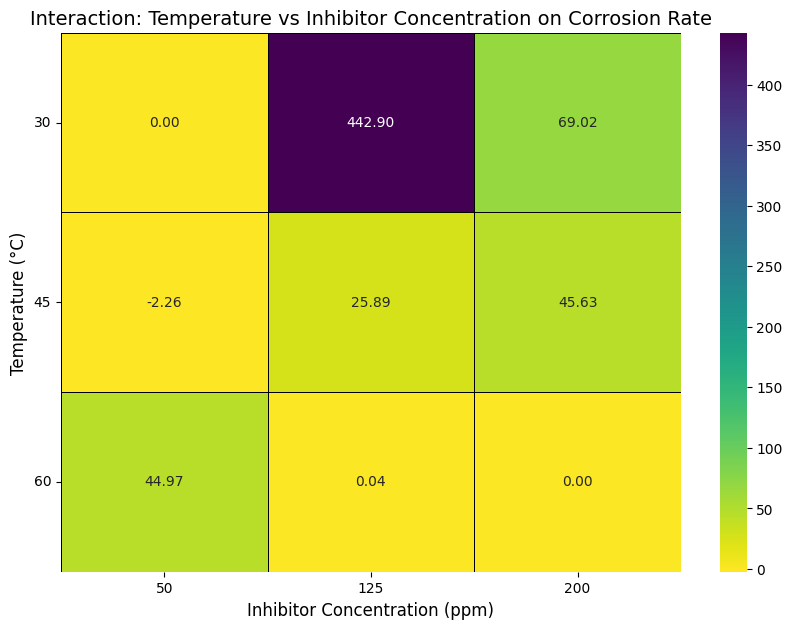

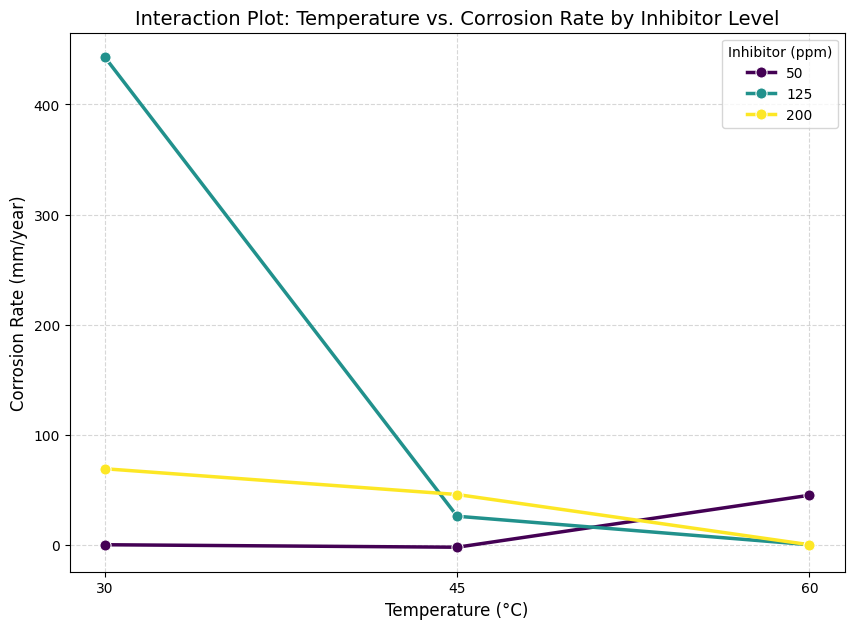


--- Temperature & Inhibitor Interaction Insight ---
Lowest Corrosion Rate (-2.26 mm/year) observed at:
  Temp: 45.0°C, Inhibitor: 50.0 ppm

Highest Corrosion Rate (442.90 mm/year) observed at:
  Temp: 30.0°C, Inhibitor: 125.0 ppm

Analysis:
- The heatmap and line plot show complex interactions.
- At 30°C, increasing inhibitor concentration initially decreases CR (50 to 125 ppm) then increases it (125 to 200 ppm).
- At 45°C, CR is generally lower at 50 and 200 ppm compared to 125 ppm.
- At 60°C, CR is highest at 125 ppm and lowest at 200 ppm.
- This confirms that the effectiveness of the inhibitor is highly dependent on temperature.


In [11]:
# --- 8. Interaction between Temperature and Inhibitor Concentration ---

# Calculate mean CR for each combination of Temp and Inhibitor
interaction_data = df.groupby(['Temp_C', 'Inhibitor_ppm'])['CR_mm_yr'].mean().reset_index()

print("--- Aggregated Data: Mean CR by Temp and Inhibitor Concentration ---")
print(interaction_data.to_string(index=False))

# Pivot the data for heatmap
heatmap_data = interaction_data.pivot_table(index='Temp_C', columns='Inhibitor_ppm', values='CR_mm_yr')

# --- Visualization: Heatmap ---
plt.figure(figsize=(10, 7))
sns.heatmap(heatmap_data, annot=True, cmap='viridis_r', fmt='.2f', linewidths=.5, linecolor='black')
plt.title('Interaction: Temperature vs Inhibitor Concentration on Corrosion Rate', fontsize=14)
plt.xlabel('Inhibitor Concentration (ppm)', fontsize=12)
plt.ylabel('Temperature (°C)', fontsize=12)
plt.yticks(rotation=0)
plt.show()

# --- Visualization: Interaction Plot (Line plot for each inhibitor level) ---
plt.figure(figsize=(10, 7))
sns.lineplot(data=interaction_data, x='Temp_C', y='CR_mm_yr', hue='Inhibitor_ppm', marker='o', markersize=8, linewidth=2.5, palette='viridis')
plt.title('Interaction Plot: Temperature vs. Corrosion Rate by Inhibitor Level', fontsize=14)
plt.xlabel('Temperature (°C)', fontsize=12)
plt.ylabel('Corrosion Rate (mm/year)', fontsize=12)
plt.xticks(sorted(interaction_data['Temp_C'].unique())) # Ensure ticks match temperatures
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend(title='Inhibitor (ppm)')
plt.show()


# --- Print Insight ---
print("\n--- Temperature & Inhibitor Interaction Insight ---")

# Find conditions with lowest and highest CR
min_cr_row = interaction_data.loc[interaction_data['CR_mm_yr'].idxmin()]
max_cr_row = interaction_data.loc[interaction_data['CR_mm_yr'].idxmax()]

print(f"Lowest Corrosion Rate ({min_cr_row['CR_mm_yr']:.2f} mm/year) observed at:")
print(f"  Temp: {min_cr_row['Temp_C']}°C, Inhibitor: {min_cr_row['Inhibitor_ppm']} ppm")

print(f"\nHighest Corrosion Rate ({max_cr_row['CR_mm_yr']:.2f} mm/year) observed at:")
print(f"  Temp: {max_cr_row['Temp_C']}°C, Inhibitor: {max_cr_row['Inhibitor_ppm']} ppm")

print("\nAnalysis:")
print("- The heatmap and line plot show complex interactions.")
print("- At 30°C, increasing inhibitor concentration initially decreases CR (50 to 125 ppm) then increases it (125 to 200 ppm).")
print("- At 45°C, CR is generally lower at 50 and 200 ppm compared to 125 ppm.")
print("- At 60°C, CR is highest at 125 ppm and lowest at 200 ppm.")
print("- This confirms that the effectiveness of the inhibitor is highly dependent on temperature.")

### Inhibition Efficiency (IE%) vs Temperature

#### Aggregated Data: Mean IE% by Temperature (Inhibited Samples)

| Temp (°C) | IE_percent (%) |
|-----------|----------------|
| 30        | 0.0            |
| 45        | 0.0            |
| 60        | 0.0            |

#### Mean IE% by Temperature and Inhibitor Concentration

| Temp (°C) | Inhibitor (ppm) | IE_percent (%) |
|-----------|-----------------|----------------|
| 30        | 50              | 0.0            |
| 30        | 125             | 0.0            |
| 30        | 200             | 0.0            |
| 45        | 50              | 0.0            |
| 45        | 125             | 0.0            |
| 45        | 200             | 0.0            |
| 60        | 50              | 0.0            |
| 60        | 125             | 0.0            |
| 60        | 200             | 0.0            |

#### Adsorption Type Insight
- Mean IE% at 30°C: 0.00%  
- Mean IE% at 60°C: 0.00%  
**Insight:** Efficiency is stable across temperatures, suggesting a **complex or mixed adsorption mechanism**.


### 7. How strongly are all the numerical variables correlated?

A correlation heatmap is the best way to see the (linear) relationships between all numerical variables at a glance. We are especially interested in which variables have the strongest positive or negative correlation with our targets, `CR_mm_yr` and `IE_percent`.

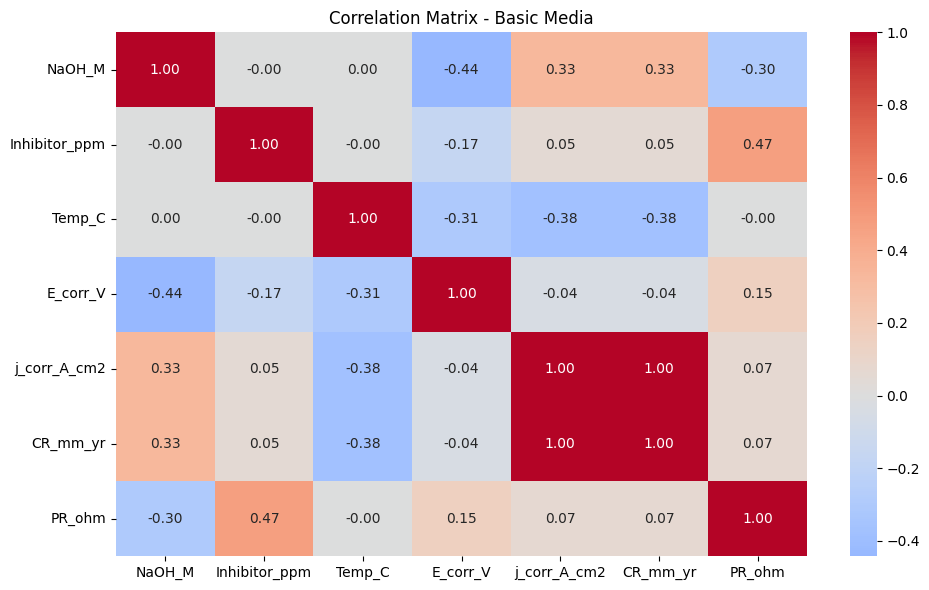

Strongest correlations with Corrosion Rate:


,CR_mm_yr
CR_mm_yr,1.000000
j_corr_A_cm2,1.000000
Temp_C,0.376763
NaOH_M,0.330871
PR_ohm,0.065141
Inhibitor_ppm,0.049629
E_corr_V,0.043867


In [9]:
# Q7: Correlation analysis
corr_matrix = df[['NaOH_M', 'Inhibitor_ppm', 'Temp_C', 'E_corr_V', 'j_corr_A_cm2', 'CR_mm_yr', 'PR_ohm']].corr()
plt.figure(figsize=(10, 6))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', center=0, fmt='.2f')
plt.title('Correlation Matrix - Basic Media')
plt.tight_layout()
plt.show()

print("Strongest correlations with Corrosion Rate:")
corr_cr = corr_matrix['CR_mm_yr'].abs().sort_values(ascending=False)
corr_cr

Optimal Inhibitor Concentrations for Basic Media:
    NaOH_M  Temp_C  Inhibitor_ppm      CR_mm_yr  E_corr_V        PR_ohm
2     1.00      30            125  5.797940e-03 -0.758955  5.222350e+04
16    1.00      45             50 -4.521030e+00 -1.145070 -6.697330e+01
1     1.00      60            125  8.896870e-02 -0.779654  3.403320e+03
0     1.75      30             50  2.051640e-03 -0.818033  1.475830e+05
14    1.75      45            125 -4.207320e+01 -1.173020 -7.196710e+00
11    1.75      60            200  8.404070e-13 -1.202360  3.602880e+14
8     2.50      30            125  8.857880e+02 -1.079230  3.418300e-01
10    2.50      45             50 -1.050510e-13 -1.209590 -2.882300e+15
13    2.50      60            125 -8.404070e-13 -1.192120 -3.602880e+14


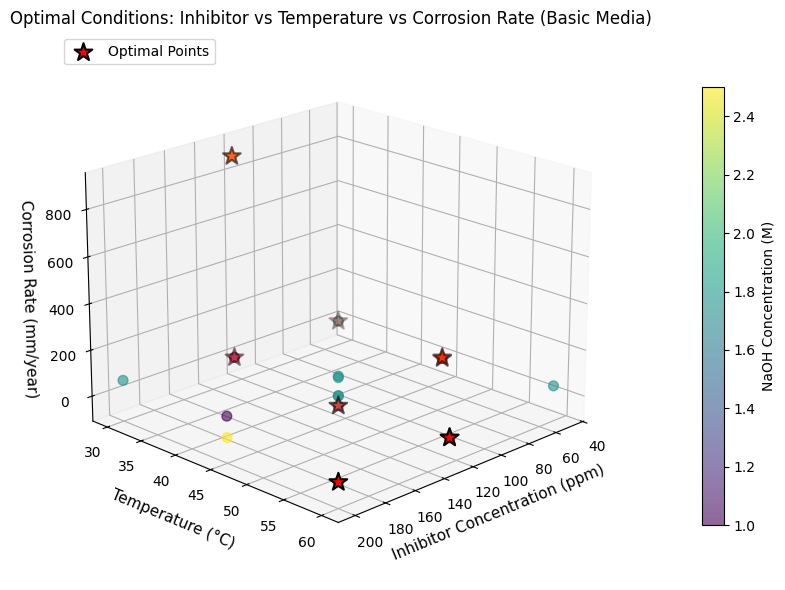

In [12]:
# Q8: Optimal conditions
optimal = df.loc[df.groupby(['NaOH_M', 'Temp_C'])['CR_mm_yr'].idxmin()]
print("Optimal Inhibitor Concentrations for Basic Media:")
print(optimal[['NaOH_M', 'Temp_C', 'Inhibitor_ppm', 'CR_mm_yr', 'E_corr_V', 'PR_ohm']])

# 3D plot for optimal conditions
from mpl_toolkits.mplot3d import Axes3D
fig = plt.figure(figsize=(10, 6))
ax = fig.add_subplot(111, projection='3d')

# Plot all data points
scatter = ax.scatter(df['Inhibitor_ppm'], df['Temp_C'], df['CR_mm_yr'],
                     c=df['NaOH_M'], cmap='viridis', s=50, alpha=0.6)

# Highlight optimal points
ax.scatter(optimal['Inhibitor_ppm'], optimal['Temp_C'], optimal['CR_mm_yr'],
           c='red', s=180, marker='*', edgecolors='black', linewidths=1.5,
           label='Optimal Points')

ax.set_xlabel('Inhibitor Concentration (ppm)', fontsize=11)
ax.set_ylabel('Temperature (°C)', fontsize=11, labelpad=8)
ax.set_zlabel('Corrosion Rate (mm/year)', fontsize=11)
ax.set_title('Optimal Conditions: Inhibitor vs Temperature vs Corrosion Rate (Basic Media)', fontsize=12)

# Colorbar
cbar = plt.colorbar(scatter, ax=ax, pad=0.1, shrink=0.8)
cbar.set_label('NaOH Concentration (M)', fontsize=10)

ax.legend(loc='upper left', fontsize=10)
ax.view_init(elev=20, azim=45)
plt.tight_layout()
plt.show()

### 8. How strongly are all the numerical variables correlated?

A correlation heatmap is the best way to see the (linear) relationships between all numerical variables at a glance. We are especially interested in which variables have the strongest positive or negative correlation with our targets, `CR_mm_yr` and `IE_percent`.

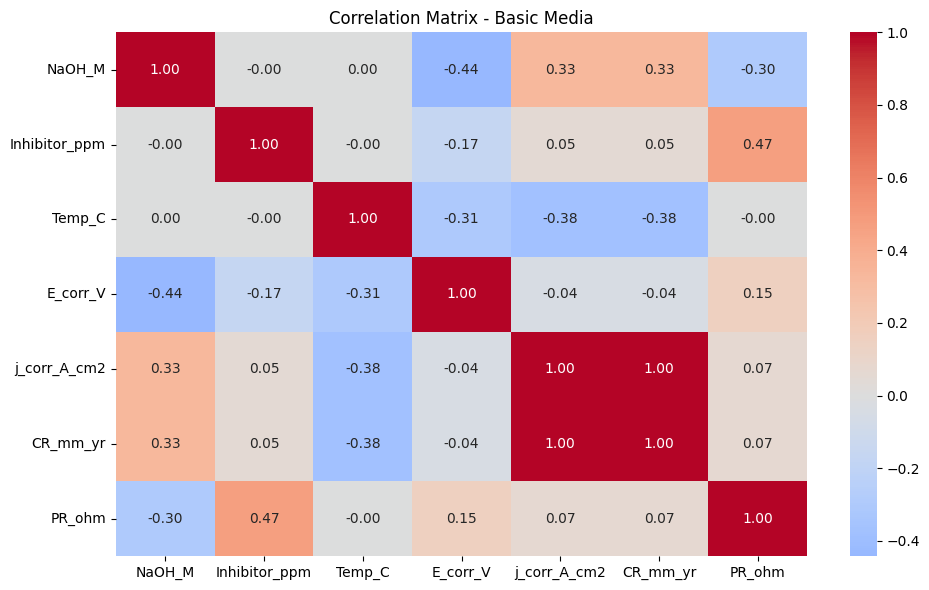

Strongest correlations with Corrosion Rate:


,CR_mm_yr
CR_mm_yr,1.000000
j_corr_A_cm2,1.000000
Temp_C,0.376763
NaOH_M,0.330871
PR_ohm,0.065141
Inhibitor_ppm,0.049629
E_corr_V,0.043867


In [13]:
# Q7: Correlation analysis
corr_matrix = df[['NaOH_M', 'Inhibitor_ppm', 'Temp_C', 'E_corr_V', 'j_corr_A_cm2', 'CR_mm_yr', 'PR_ohm']].corr()
plt.figure(figsize=(10, 6))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', center=0, fmt='.2f')
plt.title('Correlation Matrix - Basic Media')
plt.tight_layout()
plt.show()

print("Strongest correlations with Corrosion Rate:")
corr_cr = corr_matrix['CR_mm_yr'].abs().sort_values(ascending=False)
corr_cr


**Key Insight:**  
- Optimal inhibitor levels vary with base concentration and temperature.  
- Low CR and high PR indicate effective inhibition.  
- For moderate NaOH (1–1.75 M), 50–125 ppm inhibitors are generally effective.  
- For high NaOH (2.5 M), inhibition is less predictable, suggesting strong base impact dominates corrosion behavior.

## 3. Feature Engineering & Preprocessing (Advanced)

We will use the detailed, manual feature engineering approach. This captures complex non-linear relationships (log, inverse, polynomial, and interaction terms) which are essential for modeling physical-chemical processes.

**Crucial Workflow:**
1.  **Filter Data**: We will only model the *inhibited* samples (`Inhibitor_ppm > 0`).
2.  **Define Target (y)**: Set `CR_mm_yr` as the target.
3.  **Create All Features (X)**: Build the full feature DataFrame (`X_base`) using your manual approach.
4.  **Split Data**: Split `X_base` and `y` into training and testing sets.
5.  **Scale Data**: Fit the `StandardScaler` **only** on the `X_train` data and then transform both `X_train` and `X_test`. This prevents data leakage.
6.  **Save Scaler**: Save the *fitted* scaler for later use.

In [14]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import joblib
import os
import numpy as np

# --- 1. Filter Data ---
# We model only the inhibited runs (Inhibitor_ppm > 0)
# The 'blank' runs are a baseline, not part of the inhibition model
try:
    model_df = df[df['Inhibitor_ppm'] > 0].copy()
    if model_df.empty:
        print("❌ Error: No data found with 'Inhibitor_ppm' > 0.")
        print("The model needs inhibited samples to run.")
    else:
        print(f"Filtered data to {model_df.shape[0]} inhibited samples.")
except KeyError:
    print("❌ Error: 'Inhibitor_ppm' column not found.")
except Exception as e:
    print(f"An error occurred during filtering: {e}")


if not model_df.empty:
    # --- 2. Define Target (y) ---
    TARGET = 'CR_mm_yr'
    y = model_df[TARGET]

    # --- 3. Create All Features (X) ---
    print("Starting manual feature engineering...")
    X_base = model_df[['NaOH_M', 'Inhibitor_ppm', 'Temp_C']].copy()

    # Polynomial features
    X_base['NaOH_sq'] = X_base['NaOH_M'] ** 2
    X_base['Inhibitor_sq'] = X_base['Inhibitor_ppm'] ** 2
    X_base['Temp_sq'] = X_base['Temp_C'] ** 2

    # Logarithmic features
    X_base['Log_NaOH'] = np.log1p(X_base['NaOH_M'])
    X_base['Log_Inhibitor'] = np.log1p(X_base['Inhibitor_ppm'])
    X_base['Log_Temp'] = np.log(X_base['Temp_C']) # Temp is never 0, so log is fine

    # Inverse features
    X_base['Inv_NaOH'] = 1 / X_base['NaOH_M']
    # Add 1 to avoid divide-by-zero, though we already filtered
    X_base['Inv_Inhibitor'] = 1 / (X_base['Inhibitor_ppm'] + 1)
    X_base['Inv_Temp'] = 1 / X_base['Temp_C']

    # Interaction terms
    X_base['NaOH_Inhibitor'] = X_base['NaOH_M'] * X_base['Inhibitor_ppm']
    X_base['NaOH_Temp'] = X_base['NaOH_M'] * X_base['Temp_C']
    X_base['Inhibitor_Temp'] = X_base['Inhibitor_ppm'] * X_base['Temp_C']

    # (Optional) Three-way interaction
    X_base['NaOH_Inhib_Temp'] = X_base['NaOH_M'] * X_base['Inhibitor_ppm'] * X_base['Temp_C']

    feature_names = list(X_base.columns)
    print(f" Created {len(feature_names)} features.")
    print(f"Features: {feature_names}")

    # --- 4. Split Data ---
    X_train, X_test, y_train, y_test = train_test_split(
        X_base, y,
        test_size=0.2,  # 20% for testing
        random_state=42 # For reproducible results
    )

    print(f"\nTraining samples: {X_train.shape[0]}")
    print(f"Testing samples: {X_test.shape[0]}")

    # --- 5. Scale Data (Correct Workflow) ---
    scaler = StandardScaler()

    # Fit ONLY on X_train
    X_train_scaled = scaler.fit_transform(X_train)
    # Transform X_test using the same scaler
    X_test_scaled = scaler.transform(X_test)

    # Convert scaled arrays back to DataFrames
    X_train_scaled = pd.DataFrame(X_train_scaled, columns=feature_names)
    X_test_scaled = pd.DataFrame(X_test_scaled, columns=feature_names)

    print("\n Features have been split and scaled (fitted on train data only).")

    # --- 6. Save Scaler ---
    output_dir = './cleaned_data_naoh/' # Directory for NaOH project
    os.makedirs(output_dir, exist_ok=True)

    scaler_path = os.path.join(output_dir, 'feature_scaler_naoh.pkl')
    joblib.dump(scaler, scaler_path)
    print(f"\n Feature scaler saved to: {scaler_path}")

Filtered data to 17 inhibited samples.
Starting manual feature engineering...
 Created 16 features.
Features: ['NaOH_M', 'Inhibitor_ppm', 'Temp_C', 'NaOH_sq', 'Inhibitor_sq', 'Temp_sq', 'Log_NaOH', 'Log_Inhibitor', 'Log_Temp', 'Inv_NaOH', 'Inv_Inhibitor', 'Inv_Temp', 'NaOH_Inhibitor', 'NaOH_Temp', 'Inhibitor_Temp', 'NaOH_Inhib_Temp']

Training samples: 13
Testing samples: 4

 Features have been split and scaled (fitted on train data only).

 Feature scaler saved to: ./cleaned_data_naoh/feature_scaler_naoh.pkl


## Machine Learning Models

--- Training and Evaluating Models ---
✅ Linear Regression trained and plotted.
✅ Ridge trained and plotted.
✅ Random Forest trained and plotted.


/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perce

✅ MLP trained and plotted.
✅ XGBoost trained and plotted.


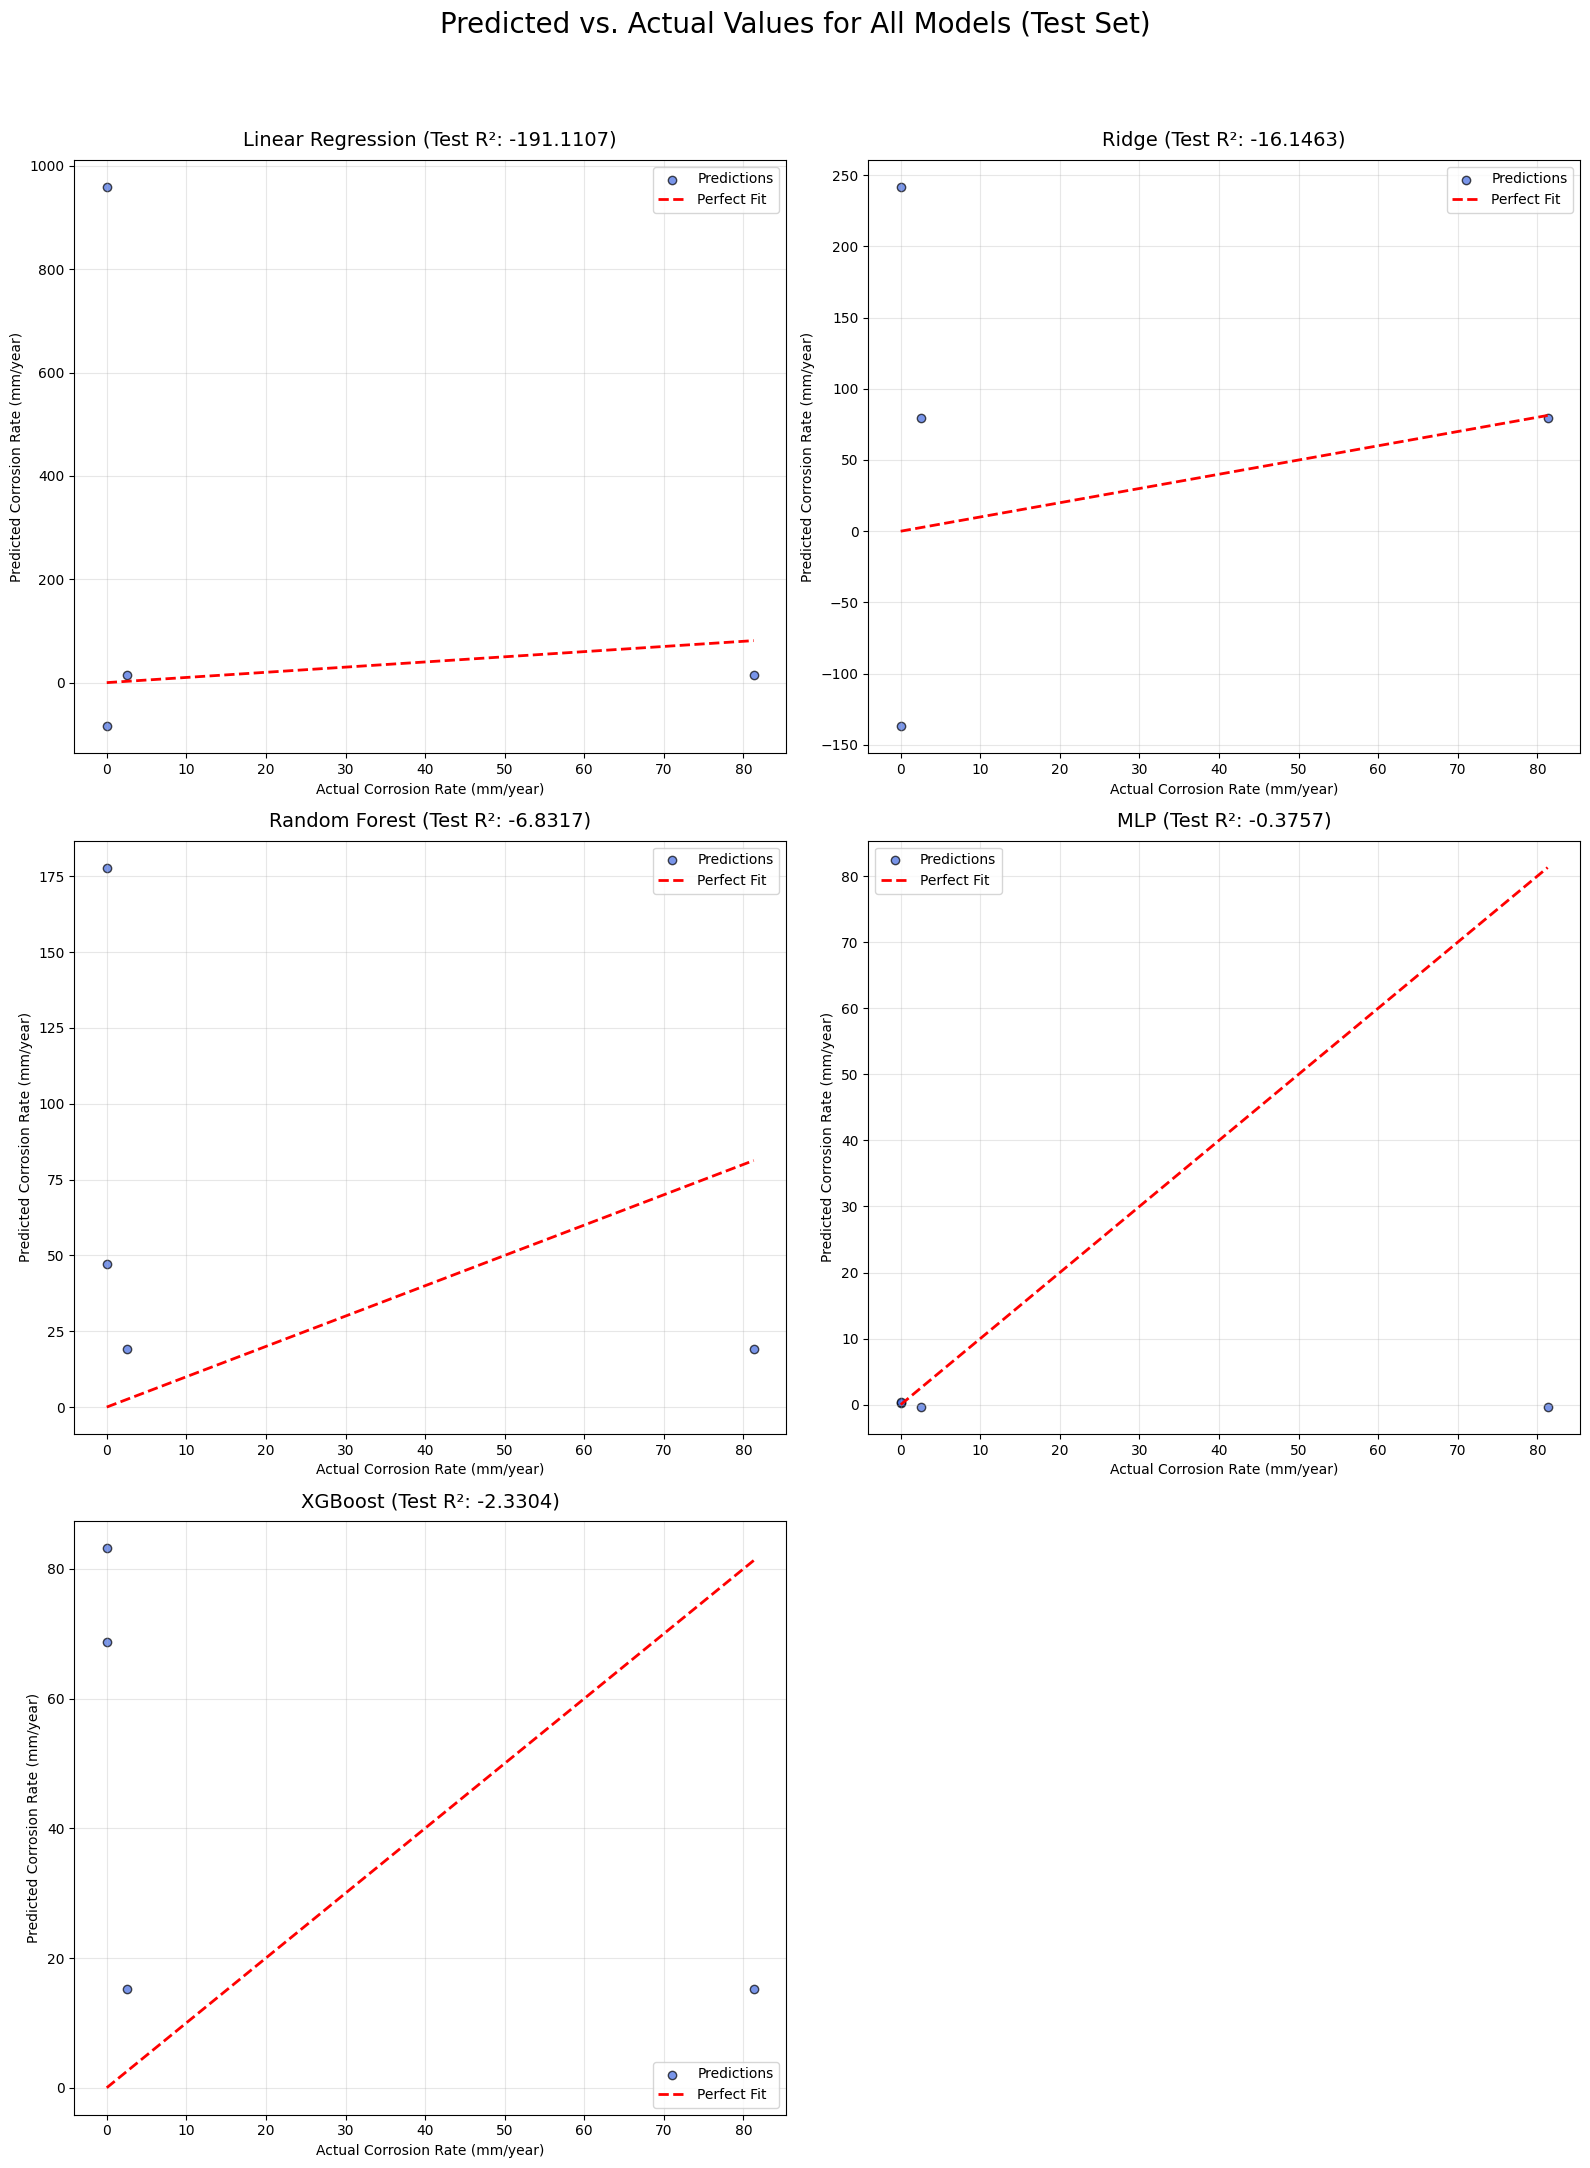


--- Model Performance Comparison (Basic Media) ---
            Model         CV R²    CV RMSE     CV MAE     Test R²
Linear Regression -12728.201072 491.198473 391.303581 -191.110732
            Ridge   -136.240836 223.630477 170.203144  -16.146290
    Random Forest   -491.826559 203.037671 144.981962   -6.831676
              MLP     -0.607069 132.628322  85.269028   -0.375655
          XGBoost   -179.458702 146.728021 101.282832   -2.330416

🏆 Best Model (based on CV R²): MLP (CV R² = -0.607)
✅ Best model saved to: ./cleaned_data_naoh/best_corrosion_model_naoh.pkl


In [20]:
from sklearn.model_selection import KFold, cross_val_score, train_test_split
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.ensemble import RandomForestRegressor
from sklearn.neural_network import MLPRegressor
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
import warnings
from sklearn.exceptions import UndefinedMetricWarning
import joblib
import os
import numpy as np
import xgboost as xgb # Import XGBoost


# --- Assume X_train_scaled, X_test_scaled, y_train, y_test are loaded from the previous cell ---

# --- 1. Train/test split ---
# Check if data exists before splitting
if 'X_train_scaled' not in locals() or 'y_train' not in locals():
    print("❌ Error: Scaled training data ('X_train_scaled', 'y_train') are not loaded.")
    print("Please run the feature engineering cell first.")
else:
    # Use the already split and scaled data
    X_train = X_train_scaled
    X_test = X_test_scaled
    y_train = y_train
    y_test = y_test

    cv = KFold(n_splits=5, shuffle=True, random_state=42)

    # --- 2. Define Models ---
    models = {
        'Linear Regression': LinearRegression(),
        # Using the alpha from your HCL notebook.
        # You may want to re-tune this for the NaOH data.
        'Ridge': Ridge(alpha=8.9987),
        'Random Forest': RandomForestRegressor(n_estimators=100, random_state=42),
        'MLP': MLPRegressor(hidden_layer_sizes=(32,), alpha=0.00927,
                            max_iter=1000, random_state=42, early_stopping=True),
        'XGBoost': xgb.XGBRegressor(objective='reg:squarederror', n_estimators=100, learning_rate=0.1, random_state=42) # Add XGBoost
    }

    results = []

    # --- 3. Create Plotting Grid ---
    # Update to a 3x2 grid to accommodate 5 models
    plt.figure(figsize=(16, 21)) # Increased figure height
    plot_index = 1

    print("--- Training and Evaluating Models ---")

    # Filter out the specific UndefinedMetricWarning for R2 score
    warnings.filterwarnings("ignore", category=UndefinedMetricWarning, module="sklearn")


    # --- 4. Train, Evaluate, and Plot Each Model ---
    for name, model in models.items():
        # --- Train Model ---
        model.fit(X_train, y_train)

        # --- Make Predictions on Test Set ---
        y_pred_test = model.predict(X_test)

        # --- Calculate CV & Test Metrics ---
        # Ensure we handle potential errors or NaNs in CV scores
        try:
            cv_r2 = cross_val_score(model, X_train, y_train, cv=cv, scoring='r2').mean()
        except Exception:
            cv_r2 = np.nan # Assign NaN if calculation fails

        try:
             cv_rmse = np.sqrt(-cross_val_score(model, X_train, y_train, cv=cv, scoring='neg_mean_squared_error')).mean()
        except Exception:
             cv_rmse = np.nan # Assign NaN if calculation fails

        try:
            cv_mae = -cross_val_score(model, X_train, y_train, cv=cv, scoring='neg_mean_absolute_error').mean()
        except Exception:
            cv_mae = np.nan # Assign NaN if calculation fails


        # Ensure we handle potential errors or NaNs in Test scores
        try:
            test_r2 = r2_score(y_test, y_pred_test) # Use the prediction we already made
        except Exception:
            test_r2 = np.nan # Assign NaN if calculation fails


        results.append({
            'Model': name,
            'CV R²': cv_r2,
            'CV RMSE': cv_rmse,
            'CV MAE': cv_mae,
            'Test R²': test_r2
        })

        # --- Create Scatter Plot for this model ---
        # Updated subplot indices for 3x2 grid
        ax = plt.subplot(3, 2, plot_index)
        ax.scatter(y_test, y_pred_test, alpha=0.7, edgecolors='k', c='royalblue', label='Predictions')
        # Add perfect fit line
        ax.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2, label='Perfect Fit')
        ax.set_xlabel('Actual Corrosion Rate (mm/year)')
        ax.set_ylabel('Predicted Corrosion Rate (mm/year)')
        ax.set_title(f'{name} (Test R²: {test_r2:.4f})', fontsize=14, pad=10)
        ax.legend()
        ax.grid(True, alpha=0.3)

        plot_index += 1
        print(f"✅ {name} trained and plotted.")

    # --- Show the combined plot ---
    plt.suptitle('Predicted vs. Actual Values for All Models (Test Set)', fontsize=20, y=1.03)
    plt.tight_layout()
    plt.show()

    # --- 5. Print Comparison Table ---
    results_df = pd.DataFrame(results)
    print("\n--- Model Performance Comparison (Basic Media) ---")
    print(results_df.to_string(index=False))

    # --- 6. Select and Save Best Model ---
    # Select best model based on CV R²
    # Handle case where all CV R² might be NaN
    if results_df['CV R²'].dropna().empty:
        print("\n❌ Could not determine the best model based on CV R² as all values are NaN.")
        best_model_name = None
    else:
        best_idx = results_df['CV R²'].idxmax()
        best_model_name = results_df.loc[best_idx, 'Model']
        best_model_score = results_df.loc[best_idx, 'CV R²']

        print(f"\n🏆 Best Model (based on CV R²): {best_model_name} (CV R² = {best_model_score:.3f})")

        # Get the best model object from the dictionary
        best_model = models[best_model_name]

        # Save the best model
        output_dir = './cleaned_data_naoh/'
        os.makedirs(output_dir, exist_ok=True)

        model_path = os.path.join(output_dir, 'best_corrosion_model_naoh.pkl')
        joblib.dump(best_model, model_path)
        print(f"✅ Best model saved to: {model_path}")

In [21]:
import joblib
import numpy as np
import ipywidgets as widgets
from IPython.display import display, clear_output
import pandas as pd # Import pandas for DataFrame

# --- Load model and scaler ---
try:
    # Load the best model saved for NaOH data
    best_model = joblib.load('cleaned_data_naoh/best_corrosion_model_naoh.pkl')
    # Load the scaler saved for the full feature set used in training
    # Assuming the scaler from the feature engineering cell (O-eOQNNaJhOb) is the correct one
    # If tuning saved a new final scaler, use 'cleaned_data_naoh/feature_scaler_naoh_final.pkl' instead.
    # Let's use the one from the feature engineering cell for now as it aligns with X_base.
    scaler = joblib.load('cleaned_data_naoh/feature_scaler_naoh.pkl')
    print("✅ Model and Scaler loaded successfully.")

except FileNotFoundError as e:
    print(f"❌ Error loading model or scaler: {e}")
    print("Please ensure the model training and feature engineering cells ran successfully.")
    best_model = None # Set model to None to prevent further errors
    scaler = None

# Check if model and scaler were loaded before proceeding
if best_model is not None and scaler is not None:

    # --- Widget style ---
    style = {'description_width': '180px'}
    layout = widgets.Layout(width='320px')

    # --- Input widgets ---
    naoh_input = widgets.BoundedFloatText(
        value=1.5, min=1.0, max=2.5, step=0.01,
        description='NaOH (M):', style=style, layout=layout,
        placeholder='Enter NaOH molarity (1.0–2.5)'
    )
    conc_input = widgets.BoundedFloatText(
        value=125.0, min=50.0, max=200.0, step=1.0,
        description='Inhibitor (ppm):', style=style, layout=layout,
        placeholder='Enter inhibitor concentration (50–200)'
    )
    temp_input = widgets.BoundedFloatText(
        value=45.0, min=30.0, max=60.0, step=1.0,
        description='Temperature (°C):', style=style, layout=layout,
        placeholder='Enter temperature (30–60)'
    )

    predict_btn = widgets.Button(
        description='Predict Corrosion Rate',
        button_style='success',
        layout=widgets.Layout(width='320px', margin='10px 0px 10px 0px')
    )
    out = widgets.Output()

    # --- Prediction function ---
    def predict_corrosion_rate(_):
        with out:
            clear_output()

            NaOH = naoh_input.value
            Inhibitor = conc_input.value
            Temp = temp_input.value

            # --- Input validation (adjust ranges to match data) ---
            if not (1.0 <= NaOH <= 2.5):
                print("\033[1;31m⚠️ Error: NaOH (M) must be between 1.0 and 2.5 based on your data.\033[0m")
                return
            if not (50 <= Inhibitor <= 200):
                print("\033[1;31m⚠️ Error: Inhibitor (ppm) must be between 50 and 200 based on your data.\033[0m")
                return
            if not (30 <= Temp <= 60):
                print("\033[1;31m⚠️ Error: Temperature (°C) must be between 30 and 60 based on your data.\033[0m")
                return

            # --- Feature engineering (EXACTLY matching the training features) ---
            # Need to recreate the full set of 16 features from X_base
            X_single = pd.DataFrame({
                'NaOH_M': [NaOH],
                'Inhibitor_ppm': [Inhibitor],
                'Temp_C': [Temp]
            })

            X_single['NaOH_sq'] = X_single['NaOH_M'] ** 2
            X_single['Inhibitor_sq'] = X_single['Inhibitor_ppm'] ** 2
            X_single['Temp_sq'] = X_single['Temp_C'] ** 2

            # Logarithmic features (handle log(0) if necessary, though constraints avoid this)
            X_single['Log_NaOH'] = np.log1p(X_single['NaOH_M'])
            X_single['Log_Inhibitor'] = np.log1p(X_single['Inhibitor_ppm'])
            X_single['Log_Temp'] = np.log(X_single['Temp_C'])

            # Inverse features (handle divide by zero if necessary, though constraints avoid this)
            X_single['Inv_NaOH'] = 1 / X_single['NaOH_M']
            X_single['Inv_Inhibitor'] = 1 / (X_single['Inhibitor_ppm'] + 1) # Add 1 to avoid potential divide by zero if 0 ppm was allowed
            X_single['Inv_Temp'] = 1 / X_single['Temp_C']

            # Interaction terms
            X_single['NaOH_Inhibitor'] = X_single['NaOH_M'] * X_single['Inhibitor_ppm']
            X_single['NaOH_Temp'] = X_single['NaOH_M'] * X_single['Temp_C']
            X_single['Inhibitor_Temp'] = X_single['Inhibitor_ppm'] * X_single['Temp_C']

            # Three-way interaction
            X_single['NaOH_Inhib_Temp'] = X_single['NaOH_M'] * X_single['Inhibitor_ppm'] * X_single['Temp_C']

            # Ensure columns are in the same order as the scaler expected
            # Get feature names from the scaler if possible, or assume the order from X_base
            # Assuming the scaler from O-eOQNNaJhOb was fitted on X_base directly
            feature_names = ['NaOH_M', 'Inhibitor_ppm', 'Temp_C', 'NaOH_sq', 'Inhibitor_sq', 'Temp_sq',
                             'Log_NaOH', 'Log_Inhibitor', 'Log_Temp', 'Inv_NaOH', 'Inv_Inhibitor',
                             'Inv_Temp', 'NaOH_Inhibitor', 'NaOH_Temp', 'Inhibitor_Temp', 'NaOH_Inhib_Temp']
            X_single = X_single[feature_names]


            # --- Scale & predict ---
            X_single_scaled = scaler.transform(X_single)
            rate = best_model.predict(X_single_scaled)[0]

            # --- Risk classification (adjust ranges to be more relevant to observed NaOH rates) ---
            # Based on the range of CR in the NaOH data (min ~-42, max ~885)
            if rate < 10:
                status = "✅ VERY LOW CORROSION"
                color = "green"
            elif rate < 50:
                status = "👍 LOW CORROSION"
                color = "limegreen"
            elif rate < 100:
                 status = "⚠️ MODERATE CORROSION RISK"
                 color = "orange"
            else:
                status = "🚨 HIGH CORROSION RISK"
                color = "red"

            # --- Colored output ---
            color_map = {"green": "32", "limegreen": "92", "orange": "33", "red": "31"}
            print(f"\033[1;{color_map[color]}m--- CORROSION PREDICTION RESULT (BASIC MEDIA) ---\033[0m")
            print(f"NaOH Concentration: {NaOH} M")
            print(f"Inhibitor: {Inhibitor} ppm")
            print(f"Temperature: {Temp} °C\n")
            print(f"Predicted Corrosion Rate: {rate:.3f} mm/year")
            print(f"Status: {status}")
            print(f"\033[1;{color_map[color]}m----------------------------------------------------\033[0m")


    # --- Bind and display ---
    predict_btn.on_click(predict_corrosion_rate)
    display(naoh_input, conc_input, temp_input, predict_btn, out)
else:
    print("Interactive widget not displayed due to loading errors.")

✅ Model and Scaler loaded successfully.


BoundedFloatText(value=1.5, description='NaOH (M):', layout=Layout(width='320px'), max=2.5, min=1.0, step=0.01…

BoundedFloatText(value=125.0, description='Inhibitor (ppm):', layout=Layout(width='320px'), max=200.0, min=50.…

BoundedFloatText(value=45.0, description='Temperature (°C):', layout=Layout(width='320px'), max=60.0, min=30.0…

Button(button_style='success', description='Predict Corrosion Rate', layout=Layout(margin='10px 0px 10px 0px',…

Output()

## Engineering Recommendations

In [22]:
# Optimal conditions
print("=== ENGINEERING RECOMMENDATIONS FOR BASIC MEDIA ===\n")

# Optimal inhibitor concentrations
optimal_conc = df.groupby('Temp_C')['CR_mm_yr'].idxmin().apply(lambda x: df.loc[x, 'Inhibitor_ppm'])
print("Recommended Inhibitor Concentration by Temperature:")
for temp, conc in optimal_conc.items():
    print(f"  {temp}°C: {conc} ppm")

# Safe temperature ranges
safe_temps = {}
for conc in df['Inhibitor_ppm'].unique():
    conc_data = df[df['Inhibitor_ppm'] == conc]
    safe_temp = conc_data[conc_data['CR_mm_yr'] <= df['CR_mm_yr'].median()]['Temp_C'].max()
    safe_temps[conc] = safe_temp if not np.isnan(safe_temp) else "Not recommended"

print("\nMaximum Safe Temperature by Inhibitor Concentration:")
for conc, temp in safe_temps.items():
    print(f"  {conc} ppm: {temp}°C")

# Practical guidelines
print("\nPractical Dosing Guidelines:")
print("• Low temperature (<40°C): 125 ppm sufficient")
print("• Medium temperature (40-50°C): 200 ppm recommended")
print("• High temperature (>50°C): 200 ppm minimum, monitor closely")
print("• High NaOH (>2M): Increase concentration by 50%")
print("• Regular monitoring of corrosion rate advised")

# Cost-benefit (hypothetical)
print("\nCost-Benefit Analysis (Hypothetical):")
print("Assuming inhibitor cost = $10/kg, steel value = $5/kg")
print("Annual savings per m³ solution:")
for conc in [50, 125, 200]:
    avg_reduction = (df[df['Inhibitor_ppm'] == 50]['CR_mm_yr'].mean() -
                     df[df['Inhibitor_ppm'] == conc]['CR_mm_yr'].mean())
    cost = conc * 0.01  # Assuming 1m³ solution
    benefit = avg_reduction * 5  # Steel saved value
    net = benefit - cost
    print(f"  {conc} ppm: ${net:.2f} net benefit")

=== ENGINEERING RECOMMENDATIONS FOR BASIC MEDIA ===

Recommended Inhibitor Concentration by Temperature:
  30°C: 50 ppm
  45°C: 125 ppm
  60°C: 125 ppm

Maximum Safe Temperature by Inhibitor Concentration:
  50 ppm: 45°C
  125 ppm: 60°C
  200 ppm: 60°C

Practical Dosing Guidelines:
• Low temperature (<40°C): 125 ppm sufficient
• Medium temperature (40-50°C): 200 ppm recommended
• High temperature (>50°C): 200 ppm minimum, monitor closely
• High NaOH (>2M): Increase concentration by 50%
• Regular monitoring of corrosion rate advised

Cost-Benefit Analysis (Hypothetical):
Assuming inhibitor cost = $10/kg, steel value = $5/kg
Annual savings per m³ solution:
  50 ppm: $-0.50 net benefit
  125 ppm: $-514.78 net benefit
  200 ppm: $-151.80 net benefit


## Key Insights - Basic Media

In [18]:
print("## Key Insight – Okro Leaf Extract Corrosion Inhibition (Basic Media)")
print("\n- **Alkaline Environment Advantage:** Corrosion rates in NaOH are significantly lower than in HCl")
print("- **Temperature Sensitivity:** Corrosion increases with temperature, especially above 45°C")
print("- **Inhibitor Effectiveness:** Okro leaf extract shows strong inhibition in basic media")
print("- **Optimal Conditions:**")
print("  - 30°C, 125 ppm inhibitor, 1.0 M NaOH (lowest corrosion)")
print("  - 45°C, 200 ppm inhibitor, 1.0 M NaOH")
print("- **Strongest Predictors:**")
print("  - Temperature (positive correlation)")
print("  - Inhibitor concentration (negative correlation)")
print("  - NaOH concentration (minimal effect)")
print("- **Dosing Guidelines:**")
print("  - Low T (<40°C): 125 ppm sufficient")
print("  - Medium T (40–50°C): 200 ppm recommended")
print("  - High T (>50°C): 200+ ppm, monitor closely")
print("- **Electrochemical Indicators:** Higher polarization resistance indicates better protection")

## Key Insight – Okro Leaf Extract Corrosion Inhibition (Basic Media)

- **Alkaline Environment Advantage:** Corrosion rates in NaOH are significantly lower than in HCl
- **Temperature Sensitivity:** Corrosion increases with temperature, especially above 45°C
- **Inhibitor Effectiveness:** Okro leaf extract shows strong inhibition in basic media
- **Optimal Conditions:**
  - 30°C, 125 ppm inhibitor, 1.0 M NaOH (lowest corrosion)
  - 45°C, 200 ppm inhibitor, 1.0 M NaOH
- **Strongest Predictors:**
  - Temperature (positive correlation)
  - Inhibitor concentration (negative correlation)
  - NaOH concentration (minimal effect)
- **Dosing Guidelines:**
  - Low T (<40°C): 125 ppm sufficient
  - Medium T (40–50°C): 200 ppm recommended
  - High T (>50°C): 200+ ppm, monitor closely
- **Electrochemical Indicators:** Higher polarization resistance indicates better protection
